Plots to describe the kinetic energy in the system.

I will look at the centre of the frame and compare it to the frame edges to describe how the energy is radiated away by inertial waves. Initially I will look at some static width and compare them.

I will then define some parameter where say 90% of the kinetic energy and see how that width changes with time.

I should also look at:
* time to peak kinetic energy
* value of peak kinetic energy
* show the frame of maximum kinetic energy - show that they look different.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm
from scipy.ndimage import gaussian_filter
from scipy.signal import savgol_filter

#####Import Ollie Tools
# dirPath = "C:/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)


####Import Ollie Tools MAC
dirPath = "/Users/olliejackson/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)

oj.thesis_plot_settings()

C:/Coding/Code
/Users/olliejackson/Coding
Thesis plot settings applied


time shape


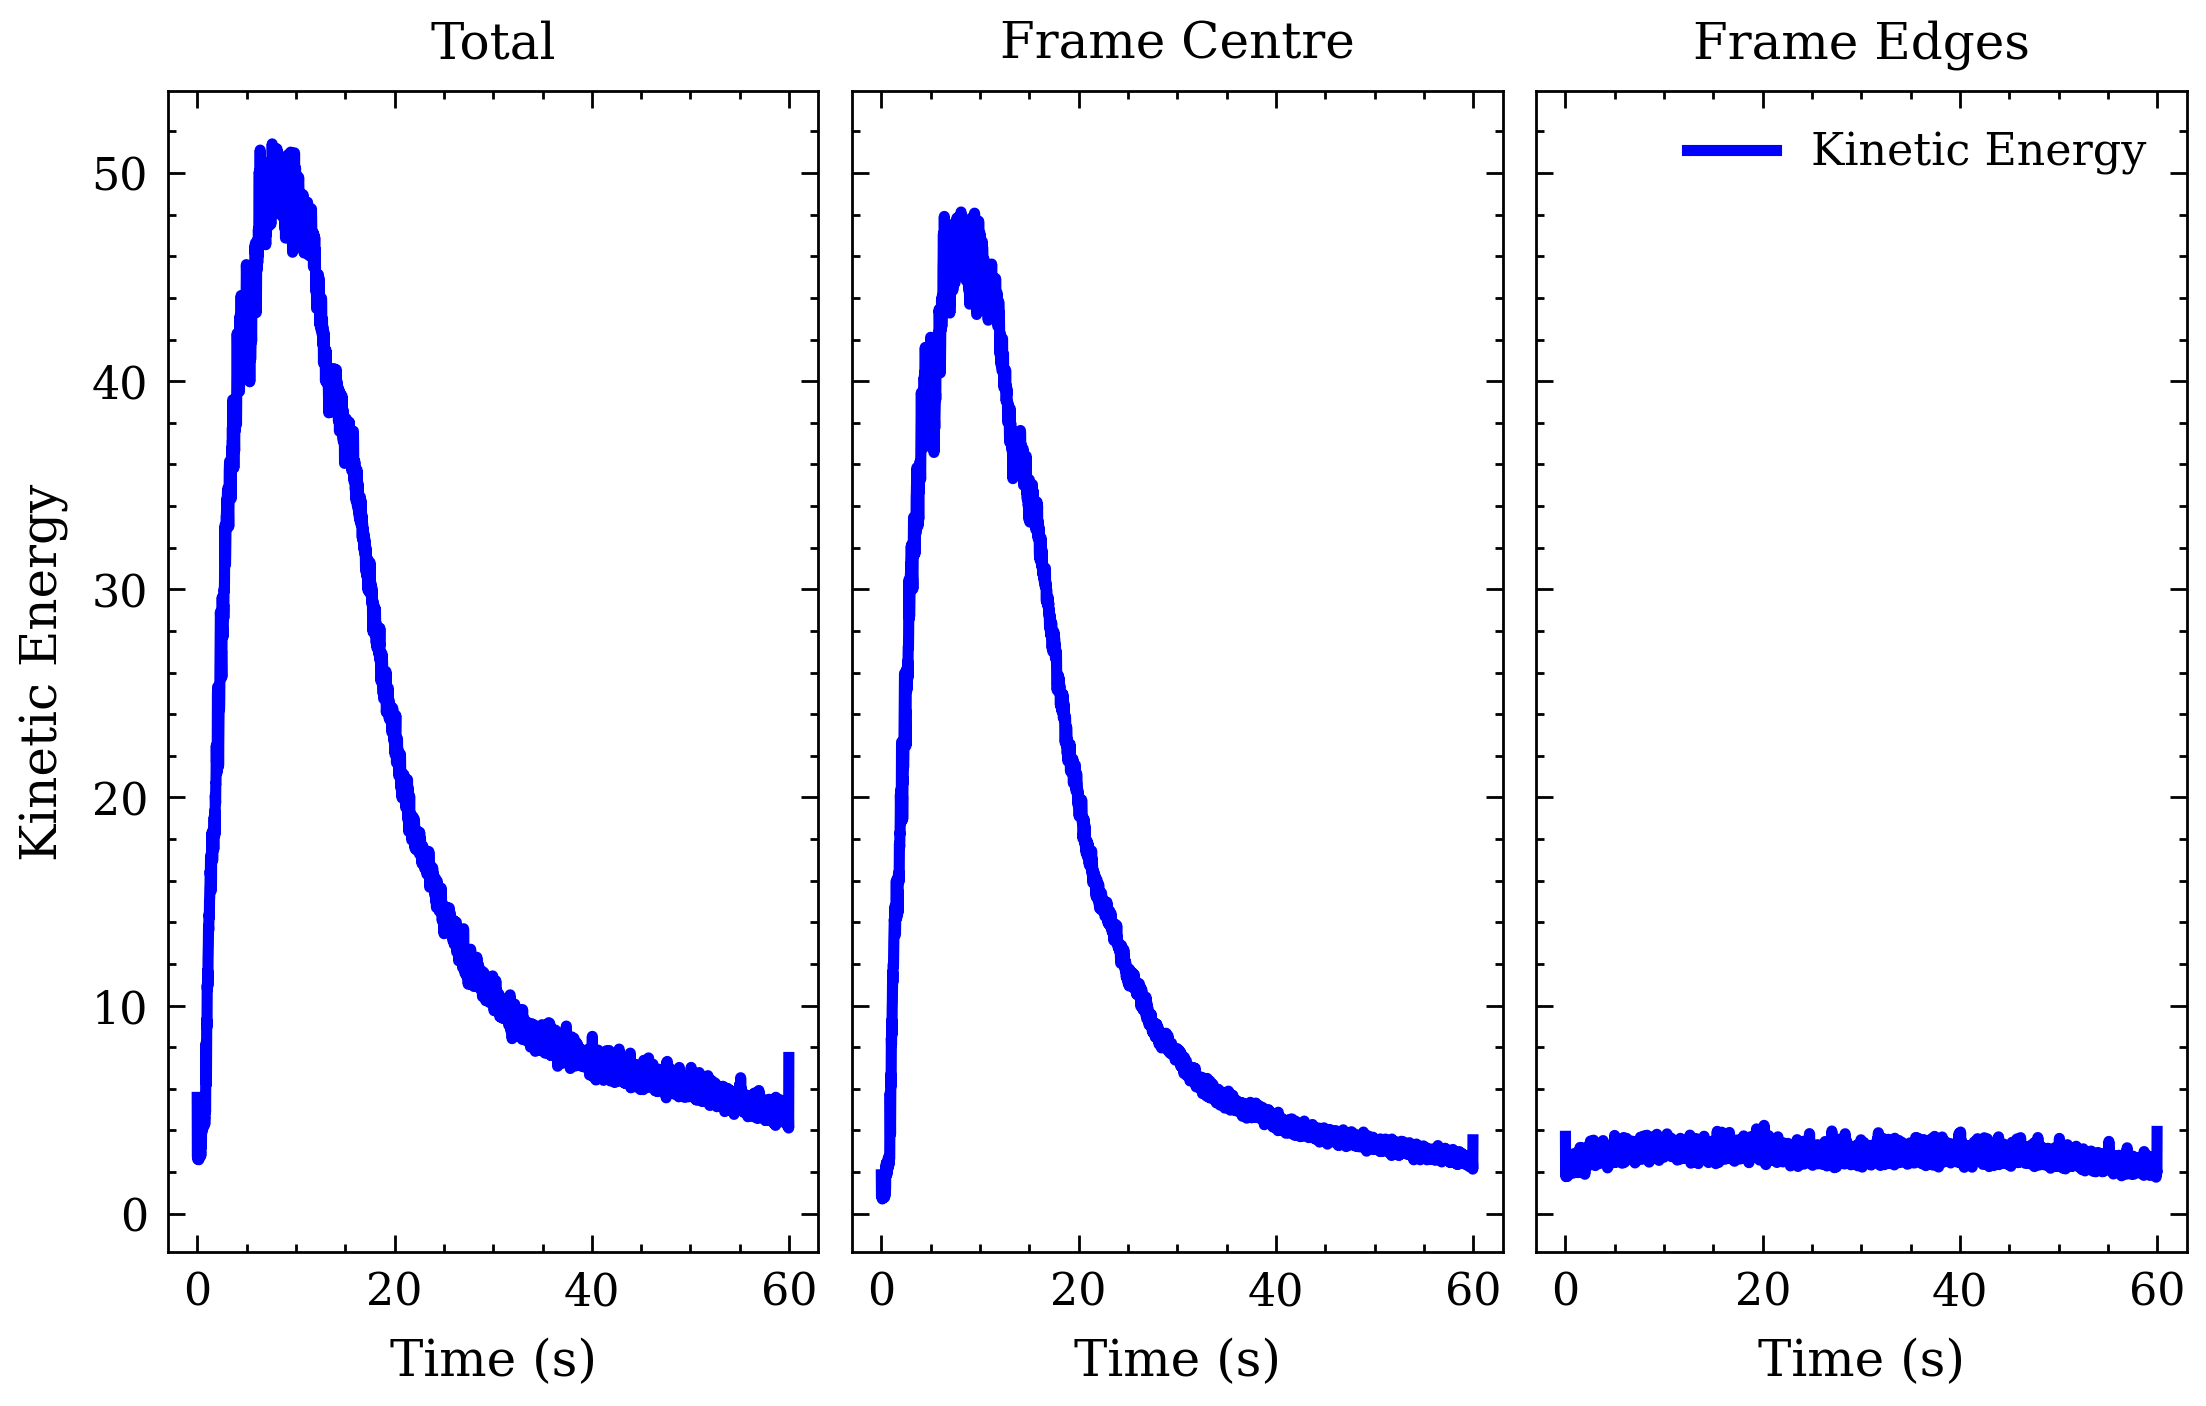

posx and posy should be finite values


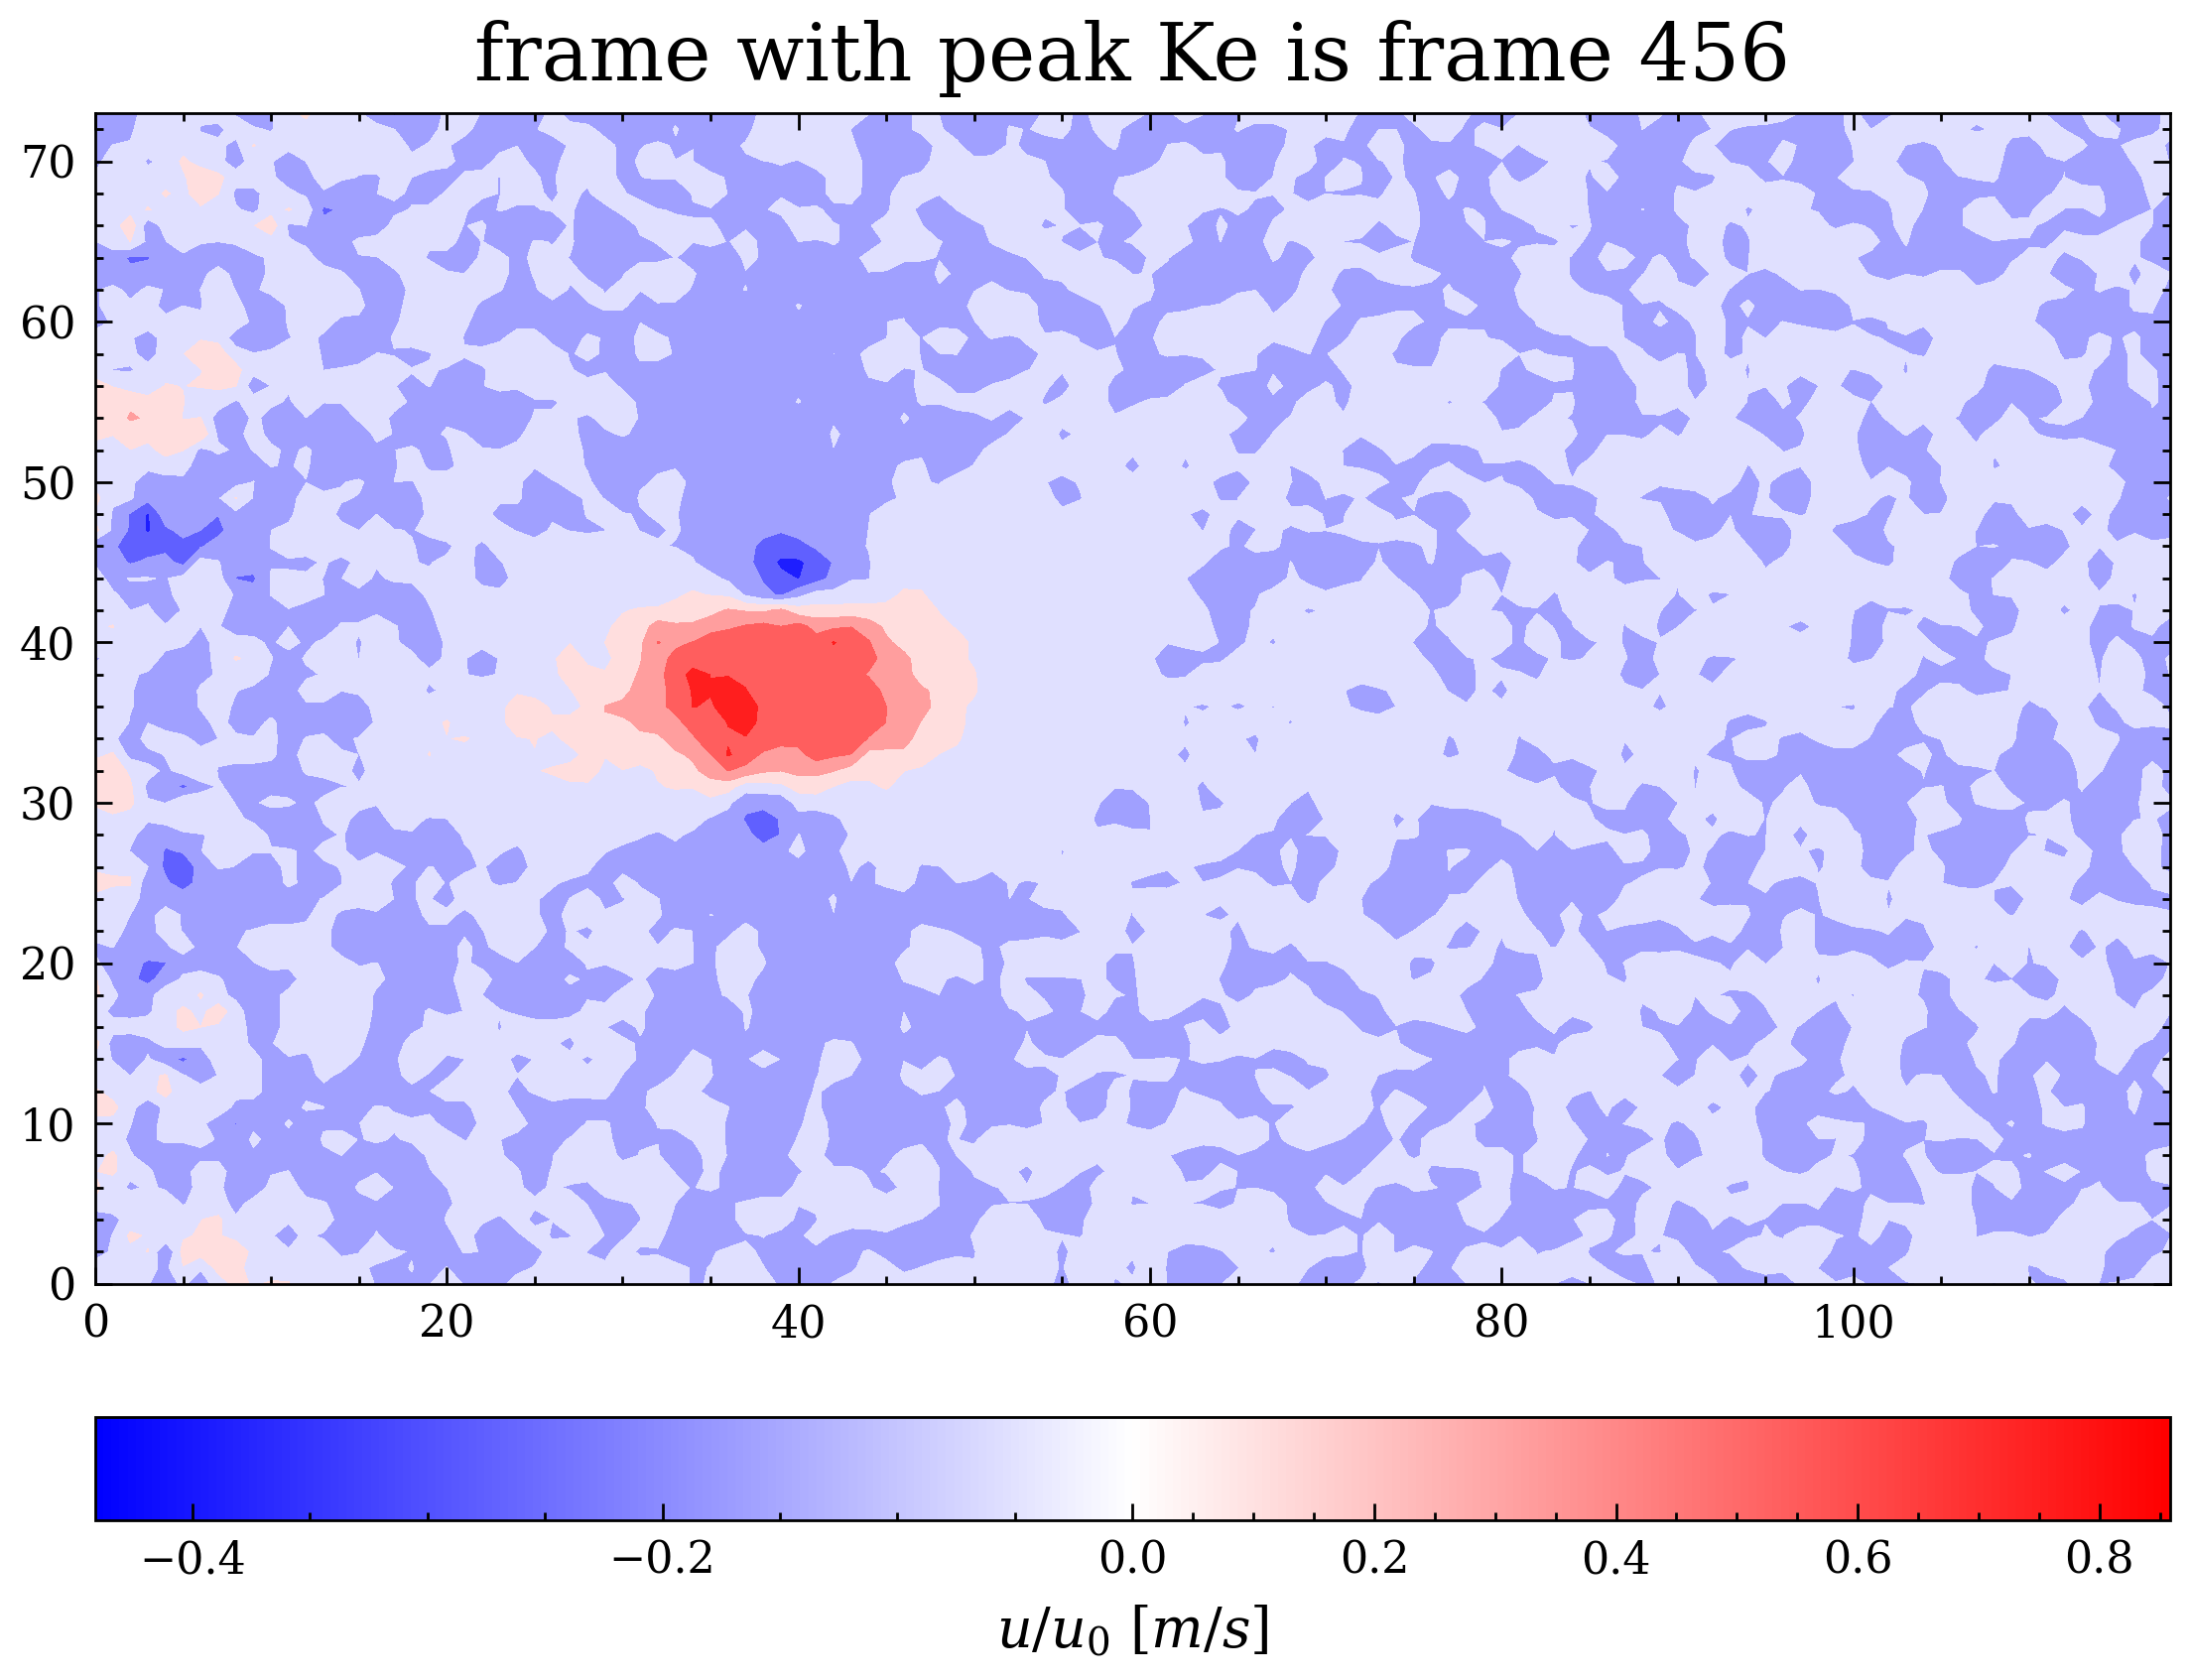

In [ ]:
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
# vels = h5file['Wide']['U200']['L100']['RPM0']
# h5file = h5py.File('E:/H5/meandataVLS.h5', 'r')
h5file = h5py.File('/Volumes/HLS_0D0/H5/WideFOV.h5', 'r')
vels = h5file['Wide']['U200']['L100']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
h5file.close()
u_gaussian, v_gaussian = gaussian_filter(u, sigma=0.7), gaussian_filter(v, sigma=0.7)
r_nd, z_nd = oj.NDUnitsForPlotsWide(u.shape[1], u.shape[2])

time = oj.frames_to_seconds(u, v, 60)
print("time shape")
# print(time.shape)

#### Calculating kinetic energy ####
kinetic_energyt, sum_kinetic_energyt = oj.sum_kinetic_energy(u_gaussian[:,:,:], v_gaussian[:,:,:])
sum_kinetic_energy_max = max(sum_kinetic_energyt)
sum_kinetic_energy_max_location = np.argmax(sum_kinetic_energyt)

#### Kinetic Energy centre and sides####
kinetic_energy_left, sum_kinetic_energy_left = oj.sum_kinetic_energy(u_gaussian[:, :25,:], v_gaussian[:, :25,:])
kinetic_energy_mid, sum_kinetic_energy_mid = oj.sum_kinetic_energy(u_gaussian[:,25:50,:], v_gaussian[:,25:50,:])
kinetic_energy_right, sum_kinetic_energy_right = oj.sum_kinetic_energy(u_gaussian[:, 50: ,:], v_gaussian[:, 50: ,:])

sum_kinetic_energy_sides = sum_kinetic_energy_left + sum_kinetic_energy_right

resum_ke = sum_kinetic_energy_sides + sum_kinetic_energy_mid

# f1, (ax1, ax2) = plt.subplots(nrows=1,ncols=2)
# ax1.plot(sum_kinetic_energyt)
# ax1.set_title("sum_kinetic_energyt")
# ax2.plot(resum_ke)
# ax2.set_title("resum_ke")
# plt.show()

#### calculate vorticity and track ####

VortLocMax, VortLocMin = oj.vorticityPeakTracking(u_gaussian, v_gaussian, u.shape[0])
VortLocMax_sav = np.zeros([VortLocMax.shape[0], VortLocMax.shape[1]])
VortLocMax_sav[:,1] = oj.FilterSpikes(VortLocMax[:,1], 50)
VortLocMax_sav[:,1] = savgol_filter(VortLocMax_sav[:,1], 21, 7)
VortLocMax_sav[:,0] = oj.FilterSpikes(VortLocMax[:,0], 50)
VortLocMax_sav[:,0] = savgol_filter(VortLocMax_sav[:,0], 21, 7)

VortLocMin_sav = np.zeros([VortLocMin.shape[0], VortLocMin.shape[1]])
VortLocMin_sav[:,1] = oj.FilterSpikes(VortLocMin[:,1], 5)
VortLocMin_sav[:,1] = savgol_filter(VortLocMin_sav[:,1], 21, 7)
VortLocMin_sav[:,0] = oj.FilterSpikes(VortLocMin[:,0], 5)
VortLocMin_sav[:,0] = savgol_filter(VortLocMin_sav[:,0], 21, 7)

#### average ring position ####
vort_local_avg = np.mean([VortLocMax_sav, VortLocMin_sav], axis=0)



f1, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, sharex = True, sharey = True, figsize = (5.5, 3.5))
# plt.suptitle(f"Kinetic Energy against time 6RPM")
# ax1.plot(time[:780], vort_local_avg[:780,1], c = "C1", label = "Ring Position")
ax1.plot(time, sum_kinetic_energyt, c = "blue", label = "Kinetic Energy")
ax1.set_title("Total", fontsize=9)
ax1.set_xlabel("Time (s)", fontsize=9)
ax1.set_ylabel("Kinetic Energy", fontsize=9)
ax2.plot(time, sum_kinetic_energy_mid, c = "blue", label = "Kinetic Energy")
ax2.set_title("Frame Centre", fontsize=9)
ax2.set_xlabel("Time (s)", fontsize=9)
# ax2.set_ylabel("Kinetic Energy")
ax3.plot(time, sum_kinetic_energy_sides, c = "blue", label = "Kinetic Energy")
ax3.set_title("Frame Edges", fontsize=9)
ax3.set_xlabel("Time (s)", fontsize=9)
# ax3.set_ylabel("Kinetic Energy")
# ax1.legend()
# ax2.legend()
ax3.legend(fontsize = 8)




norm = colors.TwoSlopeNorm(vmin=np.min(u[sum_kinetic_energy_max_location, :, :]), vcenter=0, vmax=np.max(u[sum_kinetic_energy_max_location, :, :]))
f2, ax2 = plt.subplots(nrows=1, ncols=1)
plt.title(f"frame with peak Ke is frame {str(sum_kinetic_energy_max_location)}")
ax2.contourf(u[sum_kinetic_energy_max_location, :, :], cmap = 'bwr')
f1.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='bwr'), ax=ax2, label=r'$u/u_{0} ~[m/s]$', location='bottom')
plt.show()



New Method with correct volume fraction

Text(0.5, 1.0, 'Old Method')

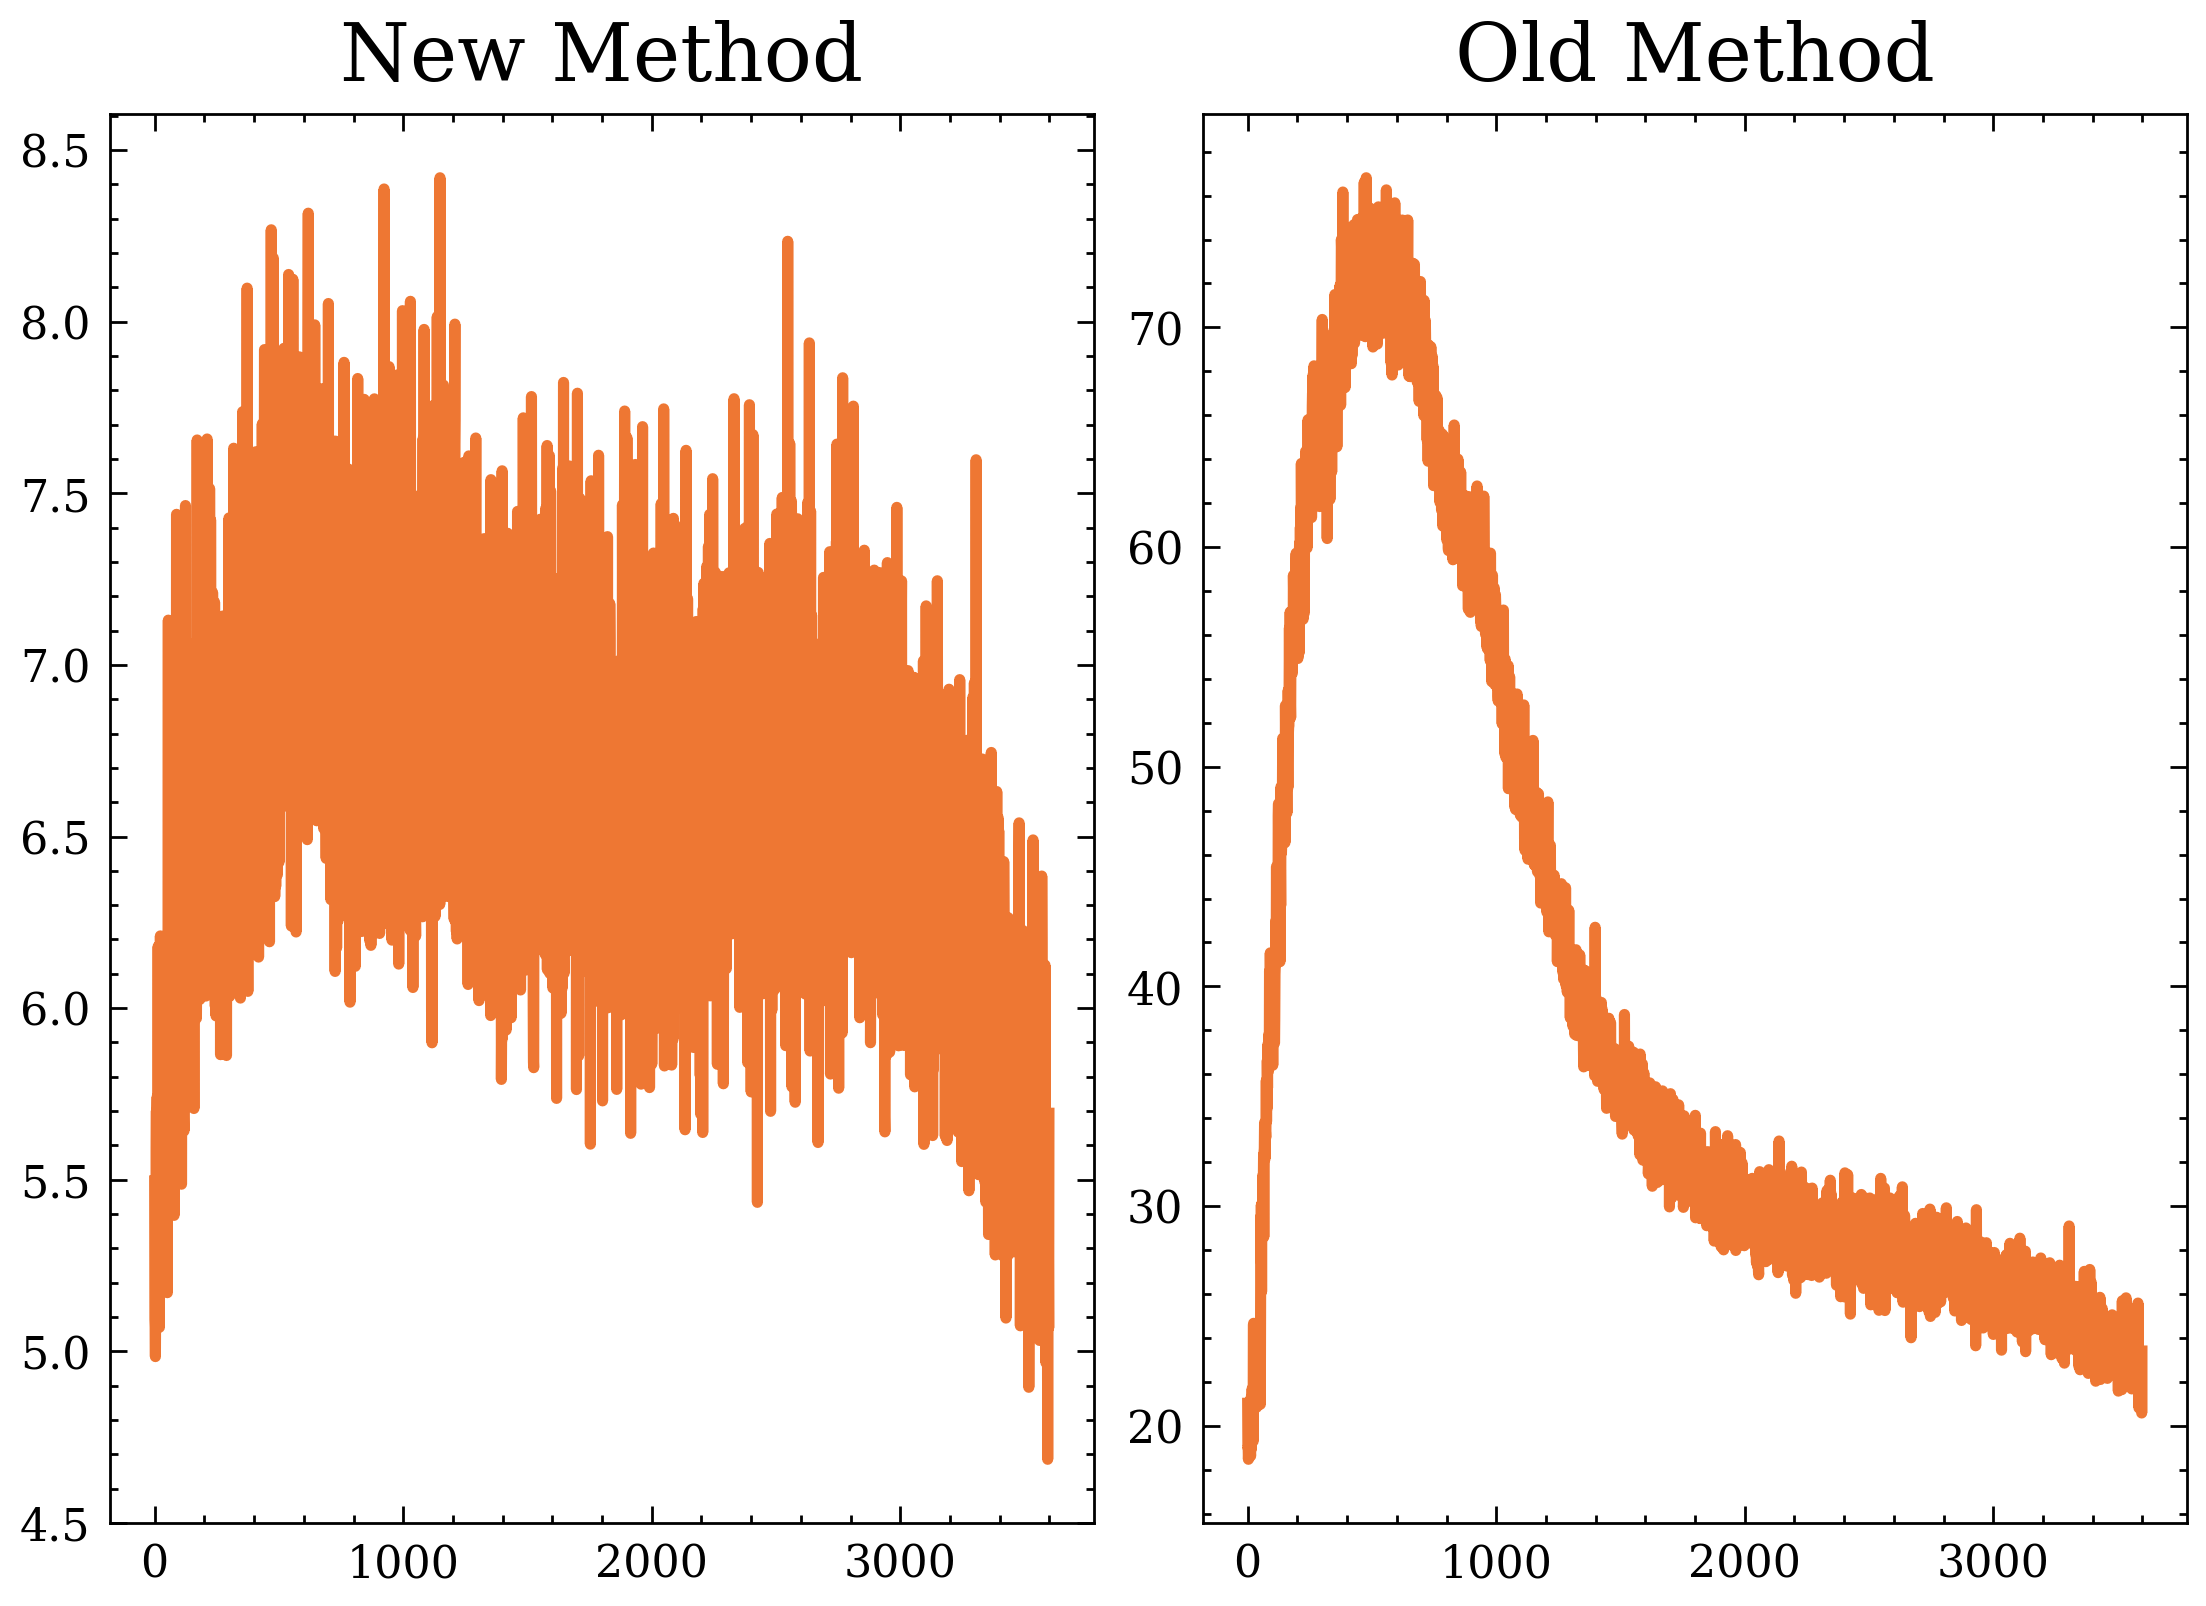

In [13]:
kinetic_energy, sum_kinetic_energy, Vol = oj.new_sum_kinetic(u, v)
r_d, z_d = oj.DimensionalScaleWide(u.shape[1], u.shape[2])


# scaled = u[500,:,:] * Vol
# fig, ax = plt.subplots(nrows=1, ncols=1)    
# # ax.contourf(z_d, r_d, scaled, cmap = 'bwr')
# plt.contourf(z_d, r_d, kinetic_energy[500,:,:], cmap = 'Blues')
# plt.colorbar()
# print(Vol[-1,:])


### old vs new method
ek, sum_ek, vol = oj.new_sum_kinetic(u, v)
ek_old, sum_ek_old = oj.sum_kinetic_energy(u, v)

f1, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
ax1.plot(sum_ek)
ax1.set_title("New Method")
ax2.plot(sum_ek_old)
ax2.set_title("Old Method")


Crowe Energy scaling

[-0.00000000e+00 -4.09061543e-11 -8.18123087e-11 ... -1.47098531e-07
 -1.47139437e-07 -1.47180343e-07]


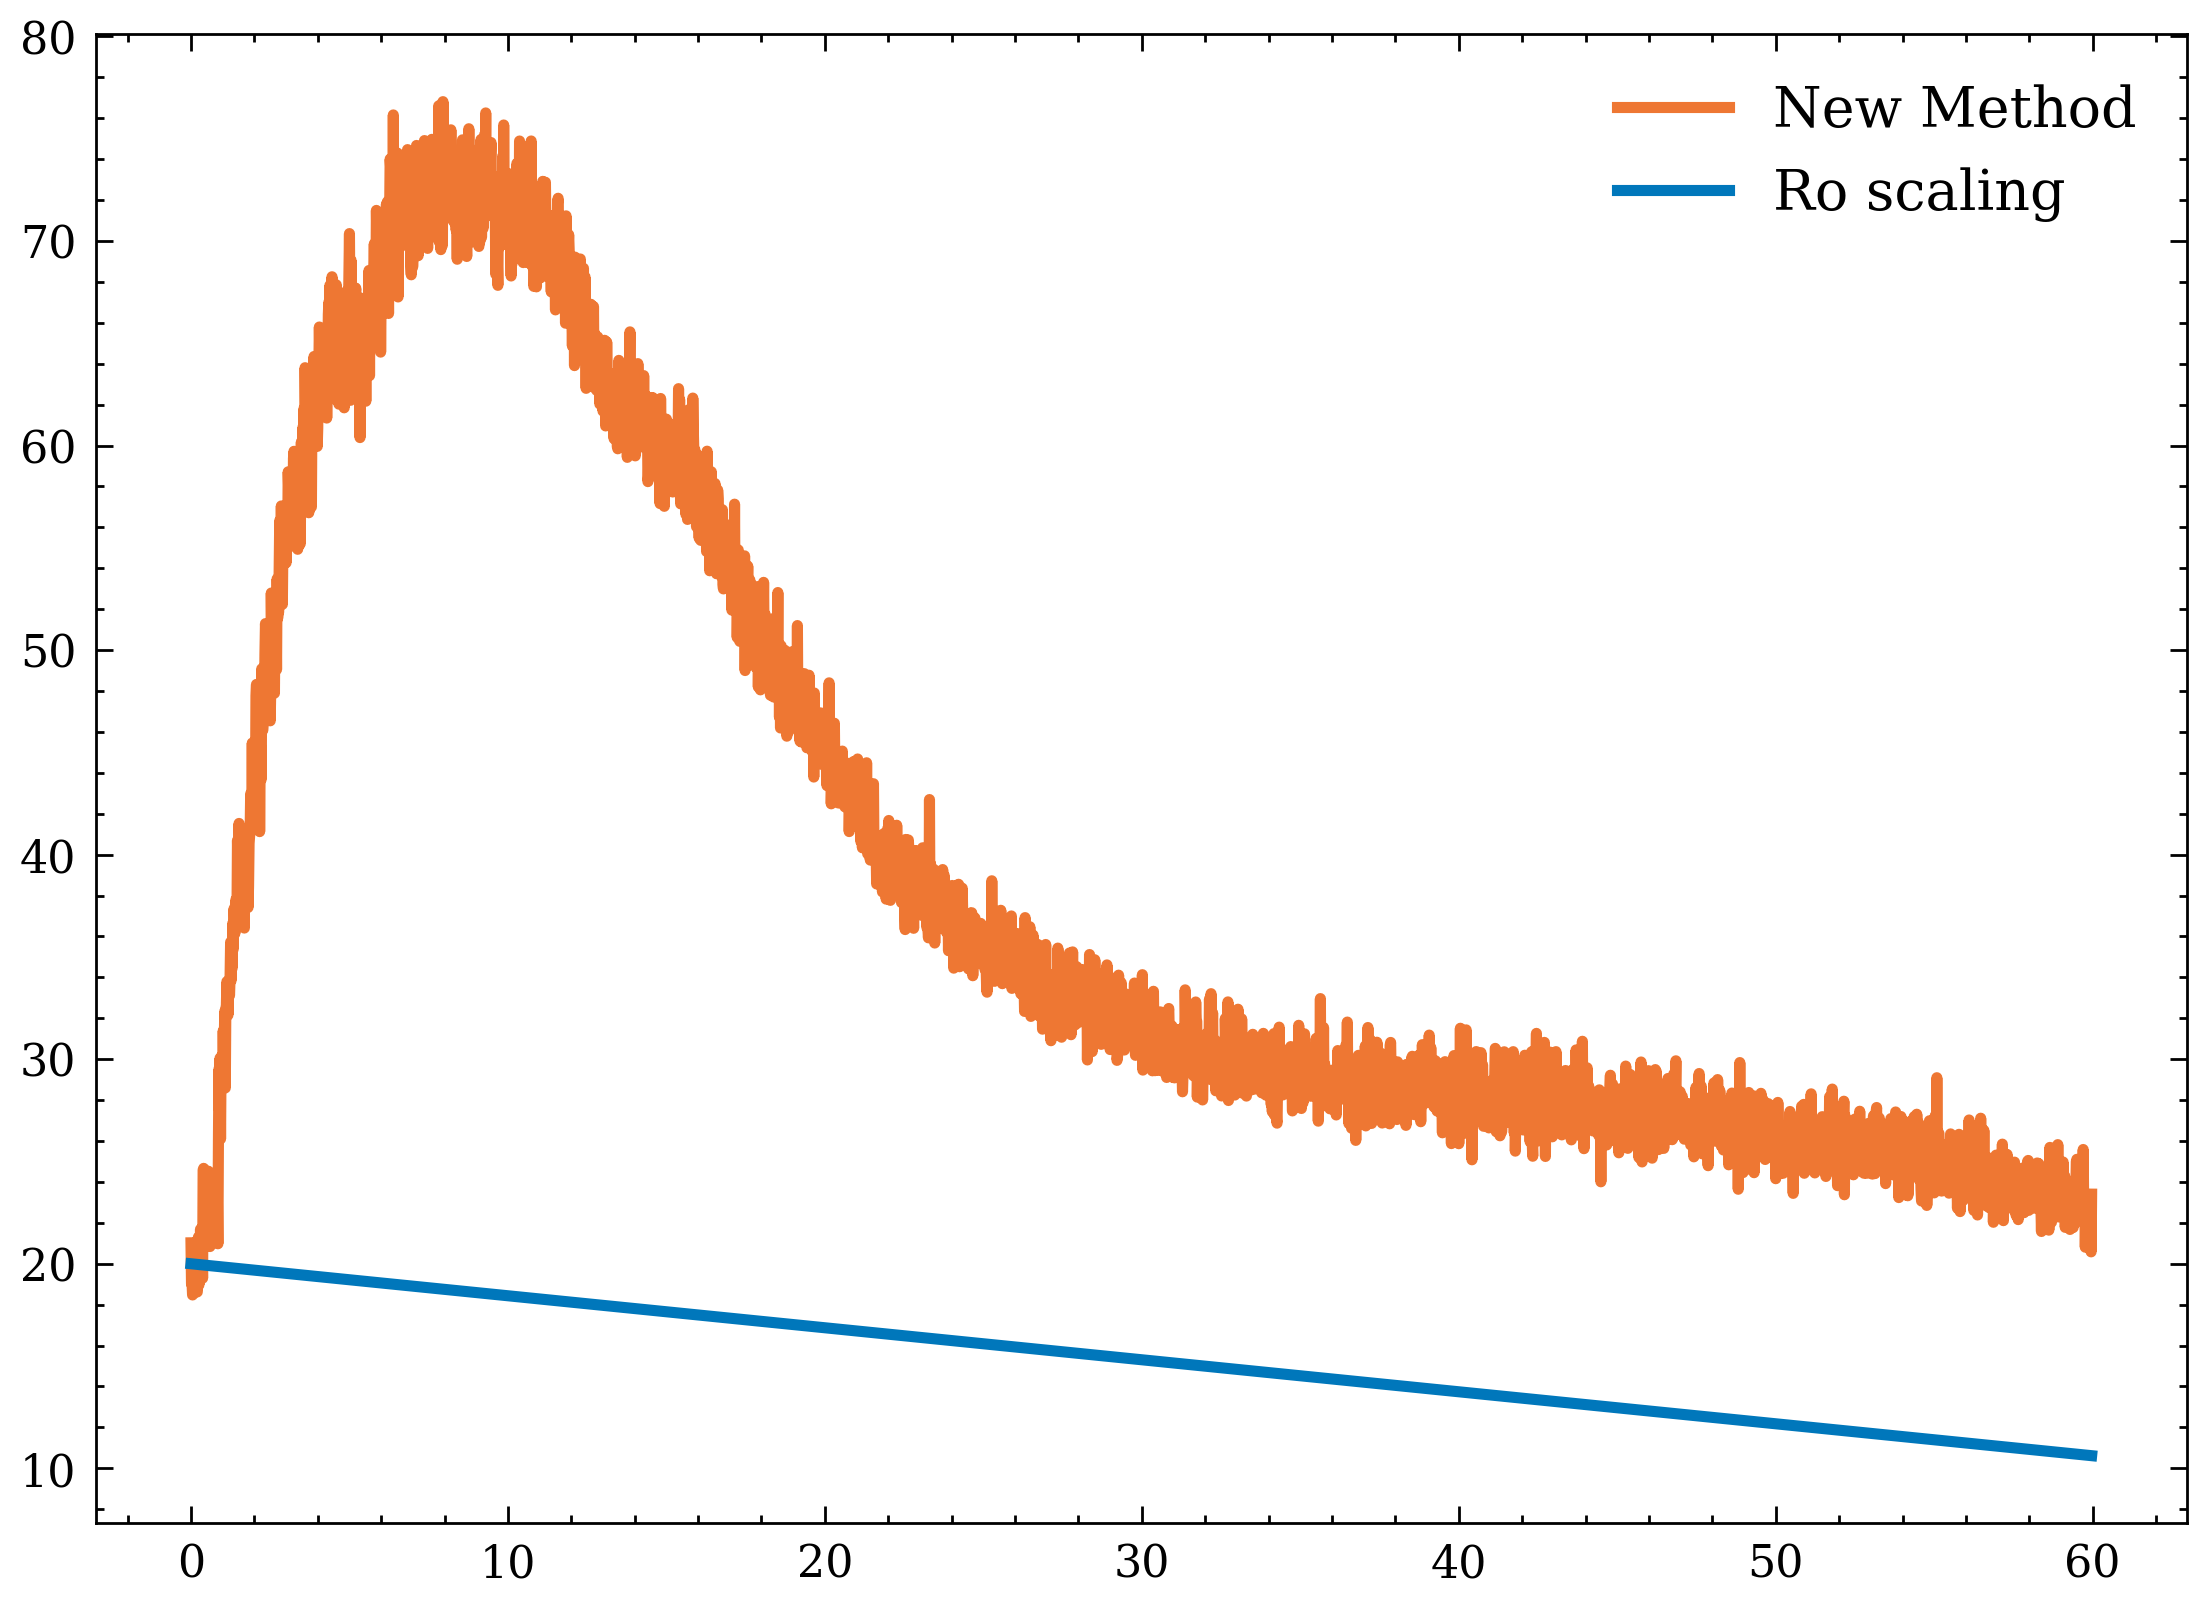

In [14]:
E_t = (-np.pi*0.05**6/4*0.2)*time

print(E_t)
Ro = oj.Ro(0.2, 12)
scale_Ro = (1/Ro**4)*time

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.plot(time, sum_ek_old, label = "New Method")
# ax.plot(time, E_t, label='scaling')
ax.plot(time, -scale_Ro+20, label='Ro scaling')
# ax.plot(time, sum_kinetic_energy_mid, c = "blue", label = "Kinetic Energy")
# ax.set_ylim(0, 7)
plt.legend()


Defining a width Criterion based on the non-rotating ring. Something like the width at which 90% or 95% of the energy is stored

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


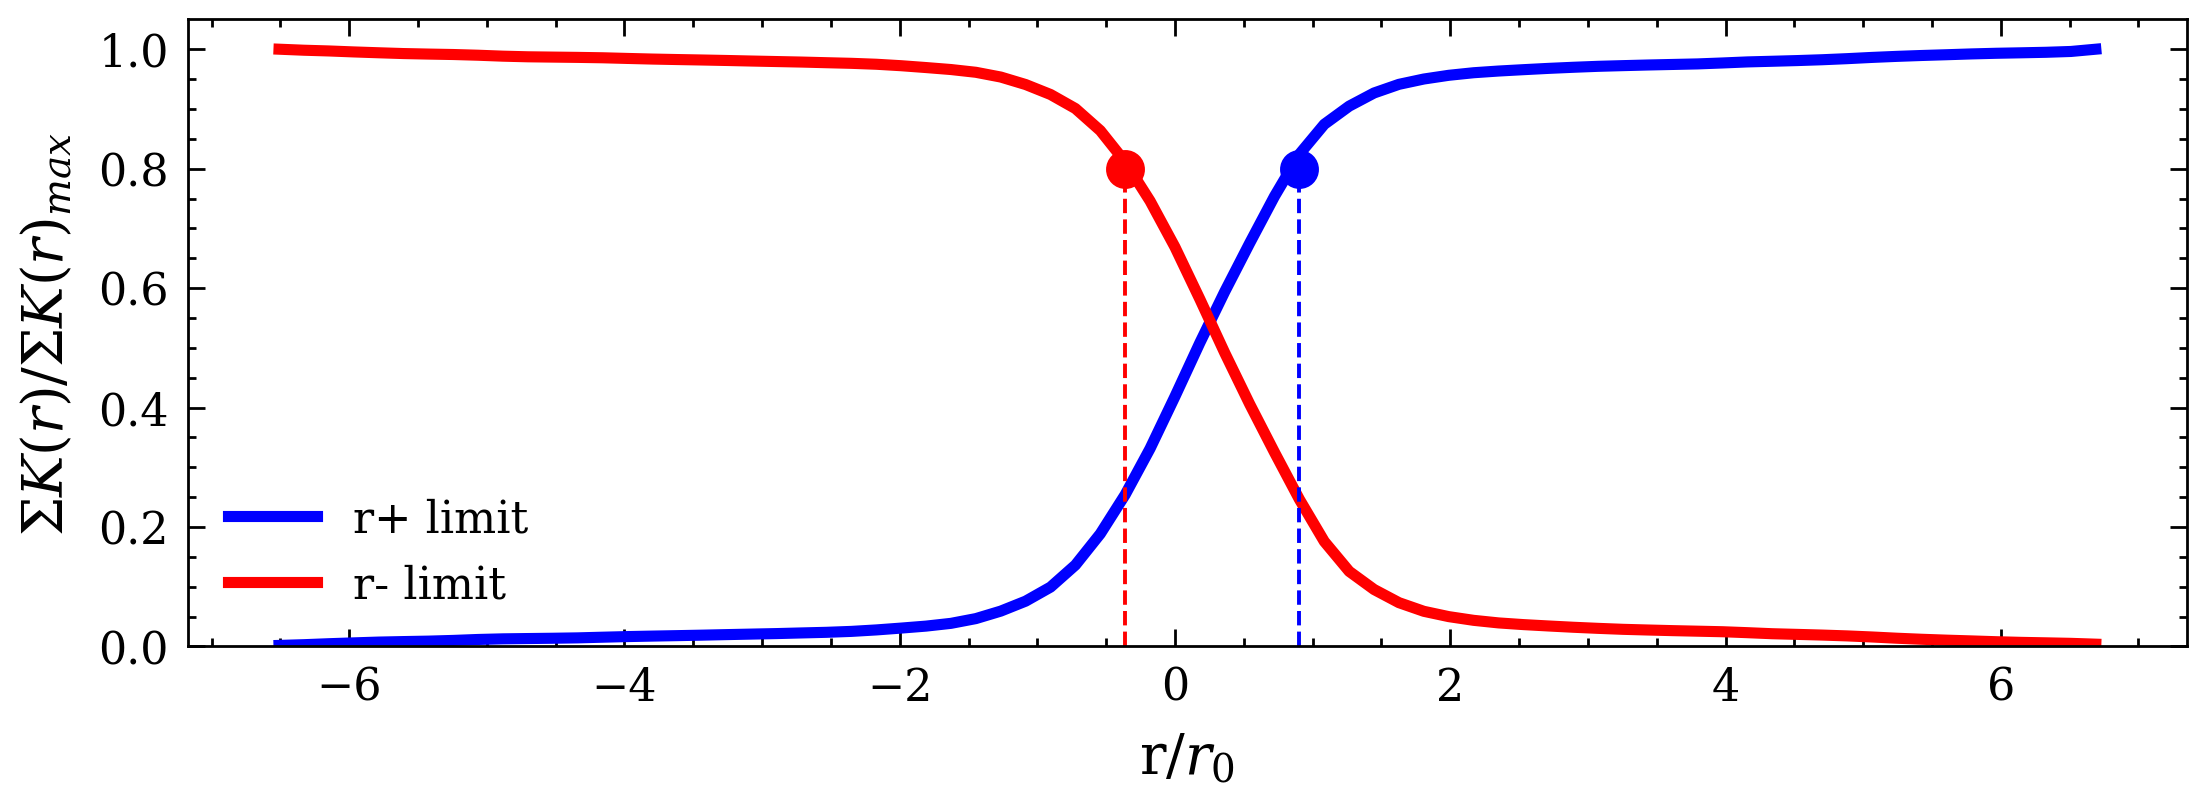

posx and posy should be finite values


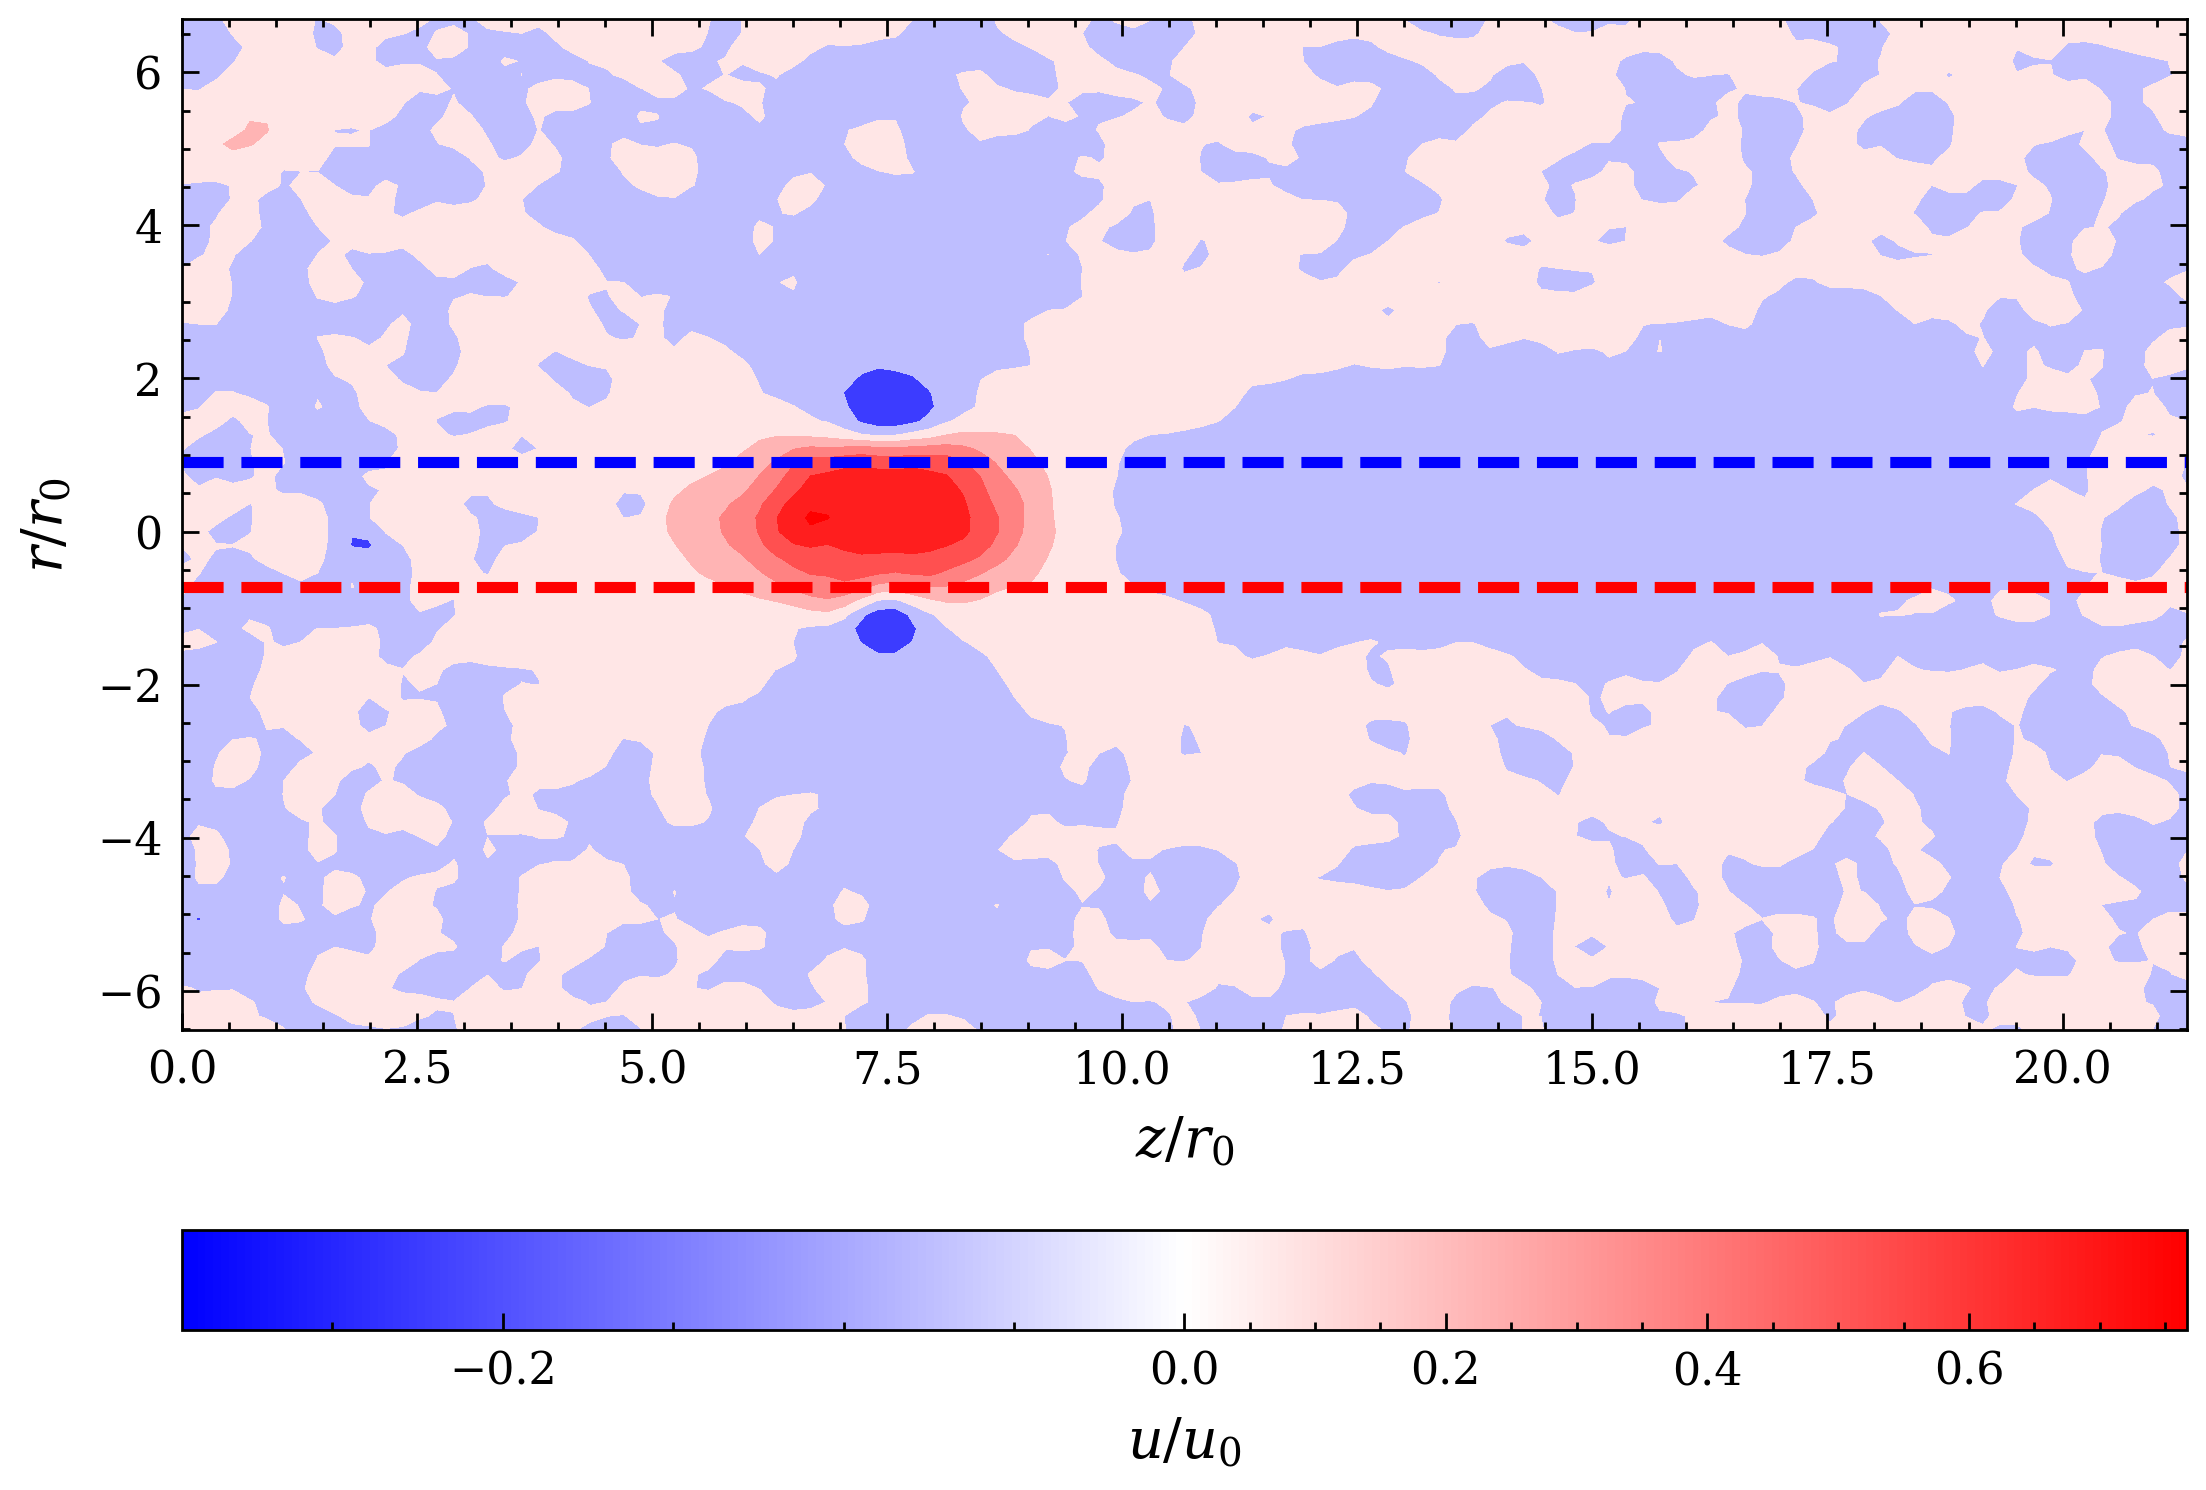

In [15]:
#### test on a single frame ####
frame = 500

u_gaussian, v_gaussian = u_gaussian-u_gaussian.mean(0), v_gaussian-v_gaussian.mean(0)
ek, sum_ek = oj.sum_kinetic_energy(u_gaussian, v_gaussian)

# ek, sum_ek, vol = oj.new_sum_kinetic(u, v)
# ek, sum_ek = oj.sum_kinetic_energy(u, v)
# ek, sum_ek = oj.sum_kinetic_energy(u, v)

vert_sum  = np.sum(ek[frame], 0)
horiz_sum = np.sum(ek[frame], 1)

vert_cumsum = np.cumsum(vert_sum)
vert_cumsumb = np.cumsum(vert_sum[::-1])

horiz_cumsum = np.cumsum(horiz_sum)
horiz_cumsumb = np.cumsum(horiz_sum[::-1])

thresh = 0.8 #how much energy of the total is within the central region
norm_horiz_cumsum = np.round((horiz_cumsum/np.max(horiz_cumsum)),3)
norm_horiz_cumsumb = np.round((horiz_cumsumb/np.max(horiz_cumsum)),3)

cutoffr = np.where(norm_horiz_cumsum>=thresh)[0]
cutoffl = np.where(norm_horiz_cumsumb<=thresh)[0]


# fig, ax = plt.subplots(nrows=1, ncols=1)
# ax.plot(horiz_sum, label = "Horizontal")
# # ax.plot(vert_sum, label = "Vertical")
# # ax.plot(vert_cumsum, label = "Cumulative Vertical")
# # ax.plot(vert_cumsumb, label = "Cumulative Vertical backwards")
# ax.plot(horiz_cumsum, label = "Cumulative Horizontal")
# ax.plot(horiz_cumsumb[::-1], label = "Cumulative Horizontal backwards")
# plt.legend(fontsize = 8)

#normalised by total value
f3, ax3 = plt.subplots(nrows=1, ncols=1, figsize = (5.5, 2))
ax3.plot(r_nd, horiz_cumsum/np.max(horiz_cumsum),        label = "r+ limit", c='b')
ax3.plot(r_nd, horiz_cumsumb[::-1]/np.max(horiz_cumsum), label = "r- limit", c='r')
ax3.scatter(r_nd[cutoffr[0]], thresh, color = 'b')
ax3.scatter(r_nd[u.shape[1]-2 - cutoffl[-1]], thresh, color = 'r')
ax3.vlines(r_nd[cutoffr[0]], 0, 0.8, color = 'b', linestyles = 'dashed', linewidth=0.7)
ax3.vlines(r_nd[u.shape[1]-2 - cutoffl[-1]], 0, 0.8, color = 'r', linestyles = 'dashed', linewidth=0.7)
ax3.set_ylim(0)
ax3.set_xlabel(r"r$/r_{0}$")
ax3.set_ylabel(r"$\Sigma K(r)/\Sigma K(r)_{max}$")
plt.legend(fontsize = 8)


norm = colors.TwoSlopeNorm(vmin=np.min(u_gaussian[frame, :, :]), vcenter=0, vmax=np.max(u_gaussian[frame, :, :]))

f2, ax2 = plt.subplots(nrows=1, ncols=1, figsize = (5.5, 3.5))
# ax2.contourf(ek[frame, :, :], cmap = 'Blues')
ax2.contourf(z_nd, r_nd, u_gaussian[frame, :, :], cmap = 'bwr', norm=norm)
ax2.hlines(r_nd[cutoffr[0]], 0, z_nd[-1], color = 'b', linestyles = 'dashed', label='r+ limit')
# ax2.hlines(r_nd[(u.shape[1] - cutoffl[-1])], 0, z_nd[-1], color = 'b', linestyle = 'dashed')
ax2.hlines(r_nd[(u.shape[1] - cutoffr[0]-1)], 0, z_nd[-1], color = 'r', linestyle = 'dashed', label='r- limit')
fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='bwr'),ax=ax2, orientation='horizontal', label=r'$u/u_0$')
# ax2.colorbar(im, cax=ax2, cmap = 'bwr', orientation='horizontal', label=r'$u/u_0$')
ax2.set_xlabel(r"$z/r_{0}$")
ax2.set_ylabel(r"$r/r_{0}$")
plt.legend(fontsize = 8)


now to track to energy width over time for all rings:
* find the ring width for one frame
* loop over every frame - probably a better way than this but cba
* save each frame width to array
* plot
* loop over all rings


6.69041095890411
5.53030303030303


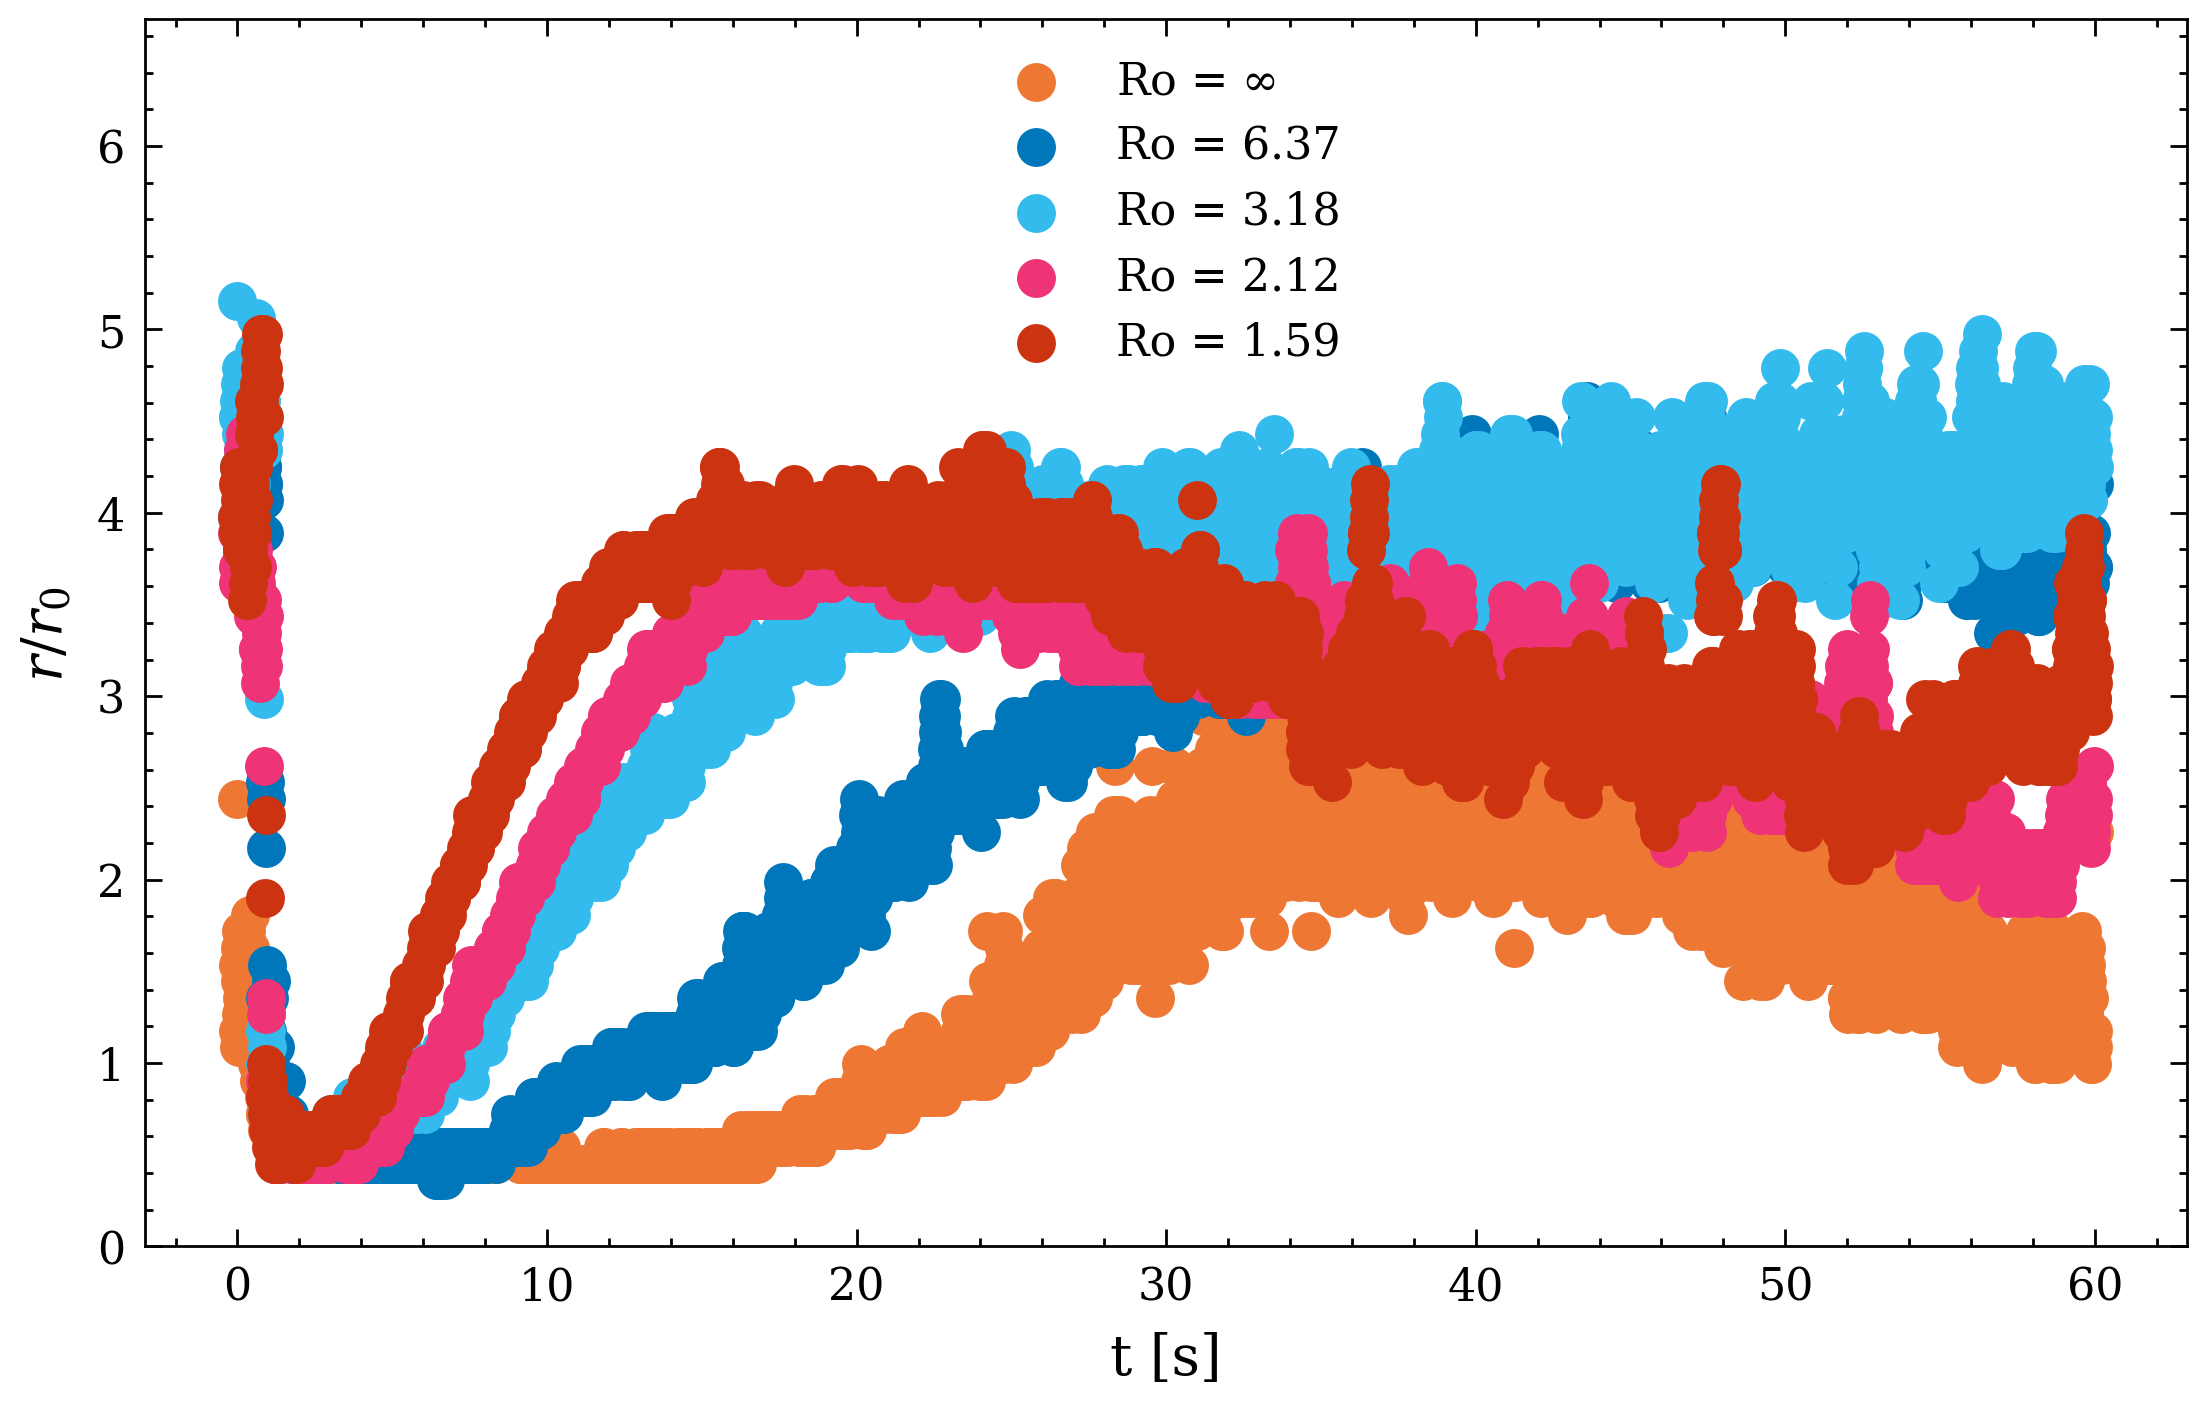

: 

In [16]:
rpms = [0,3,6,9,12]
h5file = h5py.File('/Volumes/HLS_0D0/H5/WideFOV.h5', 'r')
# vels = h5file['Wide']['U200']['L100']['RPM0']
print(r_nd[-1])
r_factor = u.shape[1]/(2*r_nd[-1])
print(r_factor)
cutoffr = np.zeros([u.shape[0]])
cutoffl = np.zeros([u.shape[0]])

fig, axs = plt.subplots(1,1,sharex=True, sharey=True, figsize=(5.5, 3.5), layout = 'constrained')
for i in range(len(rpms)):

    vels = h5file['Wide']['U200']['L100'][f'RPM{str(rpms[i])}']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVel(u, v, 60) #make suer to change this for the wide fov data

    u_gaussian, v_gaussian = gaussian_filter(u, sigma=0.7), gaussian_filter(v, sigma=0.7)
    u_gaussian, v_gaussian = u_gaussian-u_gaussian.mean(0), v_gaussian-v_gaussian.mean(0)
    ek, sum_ek = oj.sum_kinetic_energy(u_gaussian, v_gaussian)

    for j in range(u.shape[0]):

        horiz_sum = np.sum(ek[j], 1)

        horiz_cumsum = np.cumsum(horiz_sum)
        horiz_cumsumb = np.cumsum(horiz_sum[::-1])

        thresh = 0.8 #how much energy of the total is within the central region
        norm_horiz_cumsum = np.round((horiz_cumsum/np.max(horiz_cumsum)),3)
        norm_horiz_cumsumb = np.round((horiz_cumsumb/np.max(horiz_cumsum)),3)


        tempr = np.where(norm_horiz_cumsum>=thresh)[0]
        templ = np.where(norm_horiz_cumsumb<=thresh)[0]

        cutoffr[j] = tempr[0]
        cutoffl[j] = templ[-1]
        # print(cutoffr[j], cutoffl[j])
    
    cutoffM = np.mean([cutoffl, cutoffr], axis = 0)
    # axs.plot(time, cutoffr/r_factor-1, label = f"{str(rpms[i])} RPM")
    # axs.plot(time, cutoffl, label = f"{str(rpms[i])} RPM")
    # axs.plot(time, cutoffM/r_factor-1, label = f"{str(rpms[i])} RPM")
    axs.scatter(time, (cutoffM-(u.shape[1]*0.5))/r_factor, label = f"Ro = {str(oj.Ro(0.2, rpms[i]))}")


axs.set_ylim(0, r_nd[-1])
axs.set_xlabel("t [s]")
axs.set_ylabel(r"$r/r_{0}$")
plt.legend(fontsize = 8)

